In [1]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(ggplot2)
library(microshades)
library(openxlsx)
library(GenomicSEM)



Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘gdata::nobs’ by ‘lavaan::nobs’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::first’ by ‘data.table::first’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::last’ by ‘data.table::last’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::resample’ by ‘R.utils::resample’ when loading ‘GenomicSEM’”
Warning message:
“replacing p

In [2]:
sample_sizes <- read_csv(
  "
Pheno,Nca,Nco,Neff
MDD,357636,1281936,1118502.79
ADHD,38691,186843,128213.795
AN,16992,55525,46321.9
ALC,NA,NA,26853.43
ASD,18381,27969,44366.62
BIP,41917,371549,150669.892
BMI,NA,NA,681275
CAD,95830,385536,285937.77
Chrono,NA,NA,449734
CRP,NA,NA,204402
Height,NA,NA,693529
Neu,NA,NA,390278
PD,2147,7760,6665.06
PTSD,23212,151447,140475
SCZ,53386,77258,126281.975077309
Smoking,NA,NA,263954
T2D,80154,853816,251739.50
"
)

Rows: 17 Columns: 4
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Pheno
dbl (3): Nca, Nco, Neff

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Population and sample prevalences

In [3]:
#sample prevalences can be set to 0.5 as N for the munged files has been converted to effective N. It could also be odne by specifying the correct sample prevalence when convertint to the liability scale, but for compatibility purposes the neffe variant has been applied
mental_prevalences <- c("MDD" = 0.08, "ADHD" = 0.05, "ASD" = 0.012, "BIP" = 0.02, "SCZ" = 0.005)
mental_names <- names(mental_prevalences)

other_prevalences <- c(
  "ALC" = 0.16, "AN" = 0.01, "BMI" = NA,
  "CAD" = 0.05, "Chrono" = NA, "CRP" = NA,
  "Height" = NA, "Neu" = NA, "PD" = 0.03,
  "PTSD" = 0.3, "Smoking" = NA,
  "T2D" = 0.06
)
other_names <- names(other_prevalences)

all_prevalences <- c(mental_prevalences, other_prevalences)
all_names <- names(all_prevalences)

## LDSC

In [4]:
#load the paths of necessary documents as not all of them are in this directory
ld <- "/local1/hdata/REF/eur_ref_ld_chr"
weights <- "/local1/hdata/REF/eur_w_ld_chr"
samples <- c("/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/adhd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/asd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/bip_munged.sumstats.gz",
            "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/scz_munged.sumstats.gz")
other_basepath <- "/local1/hdata/sumstats/munged/" #phenotype.sumstats.gz

In [5]:
#create a matrices directory
#dir.create("matrices_jolien", showWarnings = FALSE)
#create a path for a covstruct object where you store the covariance structure of the bipolar disorders and store it in the matrices directory
covstruct_mental <- here::here("matrices_jolien",paste("mental", "R", sep = "."))
#extract population prevalence 
pop_prev <- as.vector(all_prevalences[mental_names])
#fill the samp_prev vector depending on the pop_prev vector, if NA use NA and if not use 0.5
samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
if (!file.exists(covstruct_mental)){
    covstruct_mental_ldsc <- ldsc(
        traits = samples,
        trait.names = mental_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_mental_ldsc, covstruct_mental, control = c("all", "digits17"))
}

## test ldsc with N_div6 mdd sumstats

In [6]:
samples_test <- samples <- c("/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged_ndiv6.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/adhd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/asd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/bip_munged.sumstats.gz",
            "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/scz_munged.sumstats.gz")

In [7]:
covstruct_mental <- here::here("matrices_jolien",paste("mental_ndiv6", "R", sep = "."))

if (!file.exists(covstruct_mental)){
    covstruct_mental_ldsc <- ldsc(
        traits = samples_test,
        trait.names = mental_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_mental_ldsc, covstruct_mental, control = c("all", "digits17"))
}

In [8]:
#First define the base model
#get the base covariance matrix from the matrices directory
covstruct_base_test <- dget(here::here("matrices_jolien/mental_ndiv6.R"))
#define the model using NA*Clinical to say that this parameter loading has to be freely estimated, we fix the factor variance to 1 and ensure residual genetic variance of phenotypes isnt negative
base_model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

base.fit_test <- usermodel(covstruct_base_test,
                      estimation = "DWLS",
                      model = base_model,
                      imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.385 


In [9]:
#se <- base.fit_test$results$STD_Genotype_SE
#est <- base.fit_test$results$STD_Genotype
#est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

In [10]:
#fit_sem_base_test <- semPlotModel_GSEM(base.fit_test)

In [11]:
#semPaths(fit_sem_base_test, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
   #     edge.label.cex = 1.2,
  #      esize = 2,
  #      edgeLabels = est.se,
  #      edge.label.position = 0.5
  #      )


## Summary statistics preparation

In [12]:
original_sumstats <- c("/local1/scratch/pazweifel/jolien_paper_sumstats/cleaned_sumstats/mdd_eur_neff_2.gz",
                       "/local1/scratch/pazweifel/jolien_paper_sumstats/cleaned_sumstats/adhd_eur_neff.gz",
                       "/local1/scratch/pazweifel/jolien_paper_sumstats/cleaned_sumstats/asd_eur_neff.gz",
                       "/local1/scratch/pazweifel/jolien_paper_sumstats/cleaned_sumstats/bip_eur_neff_2.gz",
                       "/local1/scratch/pazweifel/jolien_paper_sumstats/cleaned_sumstats/scz_eur_neff_2.gz")

ref <- "/local1/scratch/pazweifel/jolien_paper_sumstats/reference.1000G.maf.0.005.txt"
se.logit <- c(T,T,T,T,T)

In [13]:
mental_sumstats_path <- here::here("sumstats_jolien",paste("mental_sumstats","R", sep = "."))

if (!file.exists(mental_sumstats_path)){
    mental_sumstats <- sumstats(files = original_sumstats, trait.names = mental_names, ref = ref, se.logit = se.logit)
    dput(mental_sumstats, mental_sumstats_path, control = c("all", "digits17"))
}

## Common factor GWAS -> done in Rscript now to run outside of jupyter environment


In [14]:
#load the required files
#######covstruct_mental <- dget(here::here("matrices_jolien/mental.R"))
#mental_sumstats <- dget(here::here("sumstats_jolien/mental_sumstats.R"))
#create the path to the object you want the output to store
#####mental_common_factor_path <- here::here("common_factor_jolien","mental_common_factor.R")
####if (!file.exists(mental_common_factor_path)){
   ### mental_common_factor_gwas <- commonfactorGWAS(covstruc = covstruct_mental, SNPs = mental_sumstats, parallel = TRUE, cores = 50)
    ##dput(mental_common_factor_gwas, mental_common_factor_path, control = c("all", "digits17"))
#}

In [15]:
# load the resulsts to investigate them
#commonfactorgwas_jolien <- dget(here::here("common_factor_jolien/mental_common_factor.R"))

In [16]:
#library(qqman)

In [17]:
#head(commonfactorgwas_jolien)

In [18]:
#manhattan(filter(commonfactorgwas_jolien, warning == "0"), chr = "CHR", bp = "BP", p = "Pval_Estimate", snp = "SNP", suggestiveline = F)

In [19]:
#commonfactorgwas_jolien_filtered <- filter(commonfactorgwas_jolien, warning == "0")

In [20]:
#write_delim(commonfactorgwas_jolien_filtered, here::here("common_factor_jolien/mental_common_factor_filtered.tsv"))

In [21]:
##library(R.utils)
#gzip(here::here("common_factor_jolien/mental_common_factor_filtered.tsv"), remove = FALSE)

In [22]:
#filter(commonfactorgwas_jolien, Pval_Estimate < 1e-150)

In [23]:
#ggplot(commonfactorgwas_jolien, aes(x = as.factor(CHR), y = se_c)) + geom_boxplot(color = "darkorchid") + theme_bw() + scale_y_log10()

In [24]:
#ggplot(commonfactorgwas_jolien, aes(x = as.factor(CHR), y = est)) + geom_boxplot(color = "darkorchid") + theme_bw()

In [25]:
####summary(log10(commonfactorgwas_jolien$se_c))
###range(co####monfactorgwas_jolien$se_c, na.rm = TRUE)
##sum(commonfactorgwas_jolien$se_c < 1e-10, na.rm = TRUE)
#sum(!is.finite(commonfactorgwas_jolien$se_c))


In [26]:
###head(commonfactorgwas_jolien)
##commonfactorgwas_jolien_filter_est <- filter(commonfactorgwas_jolien, abs(est) < 0.05 & Pval_Estimate != 0)
#nrow(commonfactorgwas_jolien)
#nrow(commonfactorgwas_jolien_filter_est)
#commonfactorgwas_jolien_filter_est_se <- filter(commonfactorgwas_jolien_filter_est, abs(se_c) < 0.2 & abs(se_c) > 1e-5)
#nrow(commonfactorgwas_jolien_filter_est)
#nrow(commonfactorgwas_jolien_filter_est_se)

In [27]:
#ggplot(commonfactorgwas_jolien_filter_est_se, aes(x=as.factor(CHR), y = -log10(Pval_Estimate))) + geom_boxplot() + theme_bw()

In [28]:
#qqnorm(-log10(commonfactorgwas_jolien_filter_est_se$Pval_Estimate))
#qqline(-log10(commonfactorgwas_jolien_filter_est_se$Pval_Estimate))

In [29]:
#
#qq(filter(commonfactorgwas_jolien, Pval_Estimate != 0)$Pval_Estimate)

In [30]:
#head(mental_sumstats)

In [31]:
####extract the snp id column from the filtered dataset
##filtered_snps <- commonfactorgwas_jolien_filter_est_se$SNP
#head(filtered_snps)
##sort the sumstats file with the extracted snpvector
#mental_sumstats_filtered2 <- filter(mental_sumstats, SNP %in% filtered_snps)

In [32]:
##nrow(mental_sumstats_filtered2)
#nrow(mental_sumstats)

In [33]:
##save the filtered sumstats file in the correct folder
#dput(mental_sumstats_filtered2, here::here("sumstats_jolien","mental_sumstats_filtered2.R"), control = c("all", "digits17"))

In [34]:
######checking the distribution of pvalues in the entry sumstats
#load all the sumstats
#####sumstats_list <- list(0,0,0,0,0)
####i <- 1
###names(sumstats_list) <- mental_names
##mental_list <- mental_names
#names(mental_list) <- mental_names

In [35]:
#####
#####for (path in original_sumstats){
####    temp <- read.table(path, fill = TRUE, blank.lines.skip = TRUE, header = TRUE)
###    sumstats_list[[i]] <- temp
##    i <- i + 1
#}


In [36]:
###clean them
##sumstats_cleaned <- lapply(mental_list, function(trait){
##    filter(sumstats_list[[trait]], !is.na(N_EFF))
##    }
##                           )
    

In [37]:
##plot them
#library(qqman)

#for (trait in mental_list){
#    if (trait %in% c("MDD", "SCZ")){
#        print(trait)
#        qq(sumstats_cleaned[[trait]]$PVAL)
#    }
#    else {
#        print(trait)
#        qq(sumstats_cleaned[[trait]]$P)
#        }
#}

# Second part: External trait correlation analysis

In [38]:
# do the same thing but include the other phenotypes one by one and name them after the current phenotype used
for (phenotype in other_names){
    covstruct_pheno <- here::here("matrices_jolien",paste(phenotype,"R", sep = "."))
    #extract population prevalences
    pop_prev <- c(all_prevalences[mental_names], all_prevalences[phenotype])
    #fill the sample prevalences depending on pop vector
    samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
    #concatenate the sample vector with the bip filepaths and the specific single phenotype filepath
    samples_plus1 <- c(samples, paste0(other_basepath,phenotype,".sumstats.gz"))
    #check if file already exists
    if (!file.exists(covstruct_pheno)){
        covstruct_ldsc <- ldsc(
            traits = samples_plus1,
            trait.names = c(mental_names, phenotype),
            sample.prev = samp_prev,
            population.prev = pop_prev,
            ld = ld,
            wld = weights,
            stand = TRUE
        )
        dput(covstruct_ldsc, covstruct_pheno, control = c("all", "digits17"))
    }
}
        

## Modelling

In [39]:
#First define the base model
#get the base covariance matrix from the matrices directory
covstruct_base <- dget(here::here("matrices_jolien/mental.R"))
#define the model using NA*Clinical to say that this parameter loading has to be freely estimated, we fix the factor variance to 1 and ensure residual genetic variance of phenotypes isnt negative
base_model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

base.fit <- usermodel(covstruct_base,
                      estimation = "DWLS",
                      model = base_model,
                      imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.227 


In [40]:
#same thing but with fixed loading of 1 on the clinical, factor variance freely estimated
anchor_model <- "F1=~1*MDD+ASD+ADHD+BIP+SCZ
F1~~F1
"
anchor.fit <- usermodel(covstruct_base,
                        estimation = "DWLS",
                        model = anchor_model,
                        imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.225 


In [41]:
anchor.fit$results

,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
5,F1,=~,ASD,0.83980767,0.084138333011364,0.5858717,0.0586970967520433,0.4415230,1.840897e-23
4,F1,=~,ADHD,1.11609578,0.0831722487702843,0.6960565,0.0518706240165453,0.5245602,4.674260e-41
6,F1,=~,BIP,1.41756677,0.0807664753384755,0.9304298,0.0530116361722484,0.7011878,5.800576e-69
8,F1,=~,SCZ,1.43787383,0.0933496767278086,0.7765227,0.050413421002951,0.5852009,1.560223e-53
9,F1,~~,F1,0.02840084,0.00215341315955876,0.5679388,0.0430623497634852,0.5679388,1.018532e-39
10,MDD,~~,MDD,0.02160604,0.00229932524702286,0.4320611,0.0459801892823694,0.4320611,5.630904e-21
1,ADHD,~~,ADHD,0.09319308,0.00625105001053525,0.7248365,0.048619383570089,0.7248366,2.906855e-50
2,ASD,~~,ASD,0.08272008,0.0100332331197834,0.8050573,0.0976465221558474,0.8050574,1.657011e-16
3,BIP,~~,BIP,0.05900651,0.00505676866243293,0.5083358,0.0435635881266788,0.5083357,1.839610e-31


## Correlation Plot


MDD,ADHD,ASD,BIP,SCZ
0.03792161,0.03365065,0.03651366,0.03196533,0.02668752
0.03365065,0.05301235,0.05447988,0.03449365,0.02807998
0.03651366,0.05447988,0.09825368,0.04425660,0.04183129
0.03196533,0.03449365,0.04425660,0.05180429,0.03647317
0.02668752,0.02807998,0.04183129,0.03647317,0.04601615


x,y,values,se
<fct>,<fct>,<dbl>,<dbl>
MDD,MDD,1.00,0.04
ADHD,MDD,0.60,0.03
ASD,MDD,0.33,0.04
BIP,MDD,0.48,0.03
SCZ,MDD,0.37,0.03
MDD,ADHD,0.60,0.03
ADHD,ADHD,1.00,0.05
ASD,ADHD,0.42,0.05
BIP,ADHD,0.23,0.03


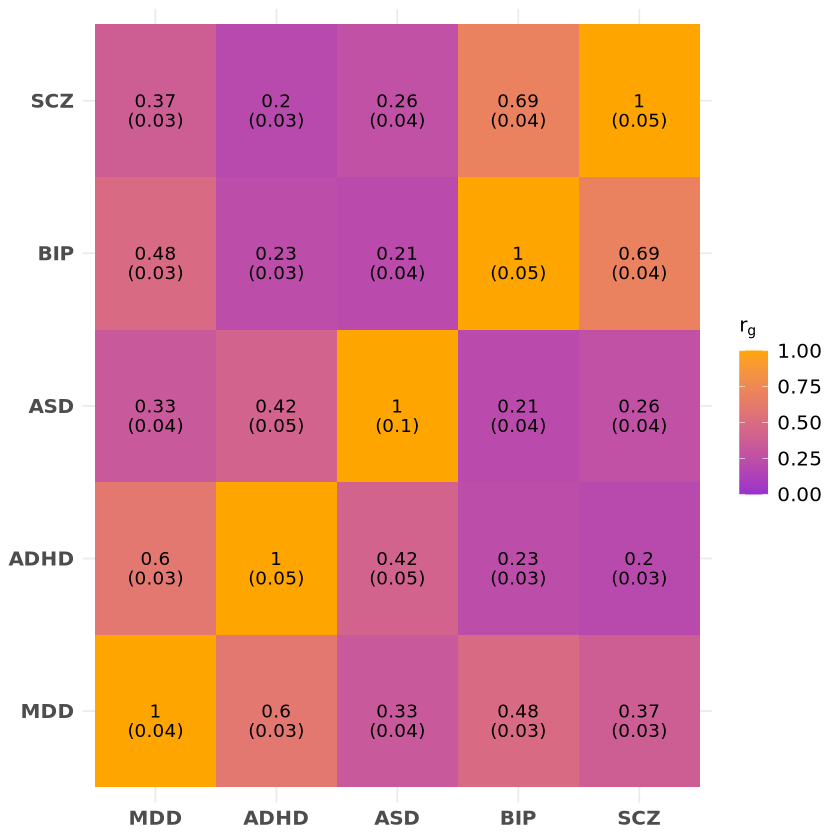

In [42]:
sstand <- covstruct_base$S_Stand
vstand <- covstruct_base$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:15), function(index) vstand[index, index])
#copy the structure of the sstand matrix
error_matrix <- sstand
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
#vectorize the matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
expanded_df
#create the ggplot
correlation_plot <- ggplot(expanded_df, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(0, max(expanded_df$values))) +
theme_minimal() +
geom_tile() +
theme(axis.text = element_text(face = "bold", size = 12), axis.title = element_blank(), legend.text = element_text(size = 12), legend.title = element_text(size = 12)) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

## Pathway models


In [43]:
#define the common and the independent pathway models and introduce a placeholder which can filled by the repsective phenotype corresponding to the used covariance matrix
#set the factor variance to 1
common.model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~{trait}
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

independent.model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~{trait}
ASD~~{trait}
ADHD~~{trait}
BIP~~{trait}
SCZ~~{trait}
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

In [44]:
#define a list with trait names named after themselves, so that that the naming remains when using this list with lapply and therefore specific elements can be accessed by name
traits <- other_names
names(traits) <- traits
traits

ALC        AN       BMI       CAD    Chrono       CRP    Height       Neu 
    "ALC"      "AN"     "BMI"     "CAD"  "Chrono"     "CRP"  "Height"     "Neu" 
       PD      PTSD   Smoking       T2D 
     "PD"    "PTSD" "Smoking"     "T2D"

In [45]:
#make a named vector with all the common models and all the applied models, take advantage of the palceholder introduced
traits_common.models <- lapply(traits, 
                               function(trait) str_glue(common.model)
)

traits_independent.models <- lapply(traits,
                                    function(trait) str_glue(independent.model)
)

In [46]:
traits_independent.models

$ALC
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~ALC
ASD~~ALC
ADHD~~ALC
BIP~~ALC
SCZ~~ALC
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$AN
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~AN
ASD~~AN
ADHD~~AN
BIP~~AN
SCZ~~AN
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$BMI
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~BMI
ASD~~BMI
ADHD~~BMI
BIP~~BMI
SCZ~~BMI
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$CAD
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~CAD
ASD~~CAD
ADHD~~CAD
BIP~~CAD
SCZ~~CAD
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$Chrono
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~Chrono
ASD~~Chrono
ADHD~~Chrono
BIP~~Chrono
SCZ~~Chrono
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$CRP
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~CRP
ASD~~CRP
ADHD~~CRP
BIP~~CRP
SCZ~~CRP
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$Height
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~Height
ASD~~Height
ADHD~~Height
BIP~~Height
SCZ~~Height
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$Neu
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~Neu
ASD~~Neu
ADHD~~Neu
BIP~~Neu
SCZ~~Neu
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$PD
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~PD
ASD~~PD
ADHD~~PD
BIP~~PD
SCZ~~PD
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$PTSD
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~PTSD
ASD~~PTSD
ADHD~~PTSD
BIP~~PTSD
SCZ~~PTSD
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$Smoking
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~Smoking
ASD~~Smoking
ADHD~~Smoking
BIP~~Smoking
SCZ~~Smoking
F1~~1*F1
MDD~~a*MDD
a > 0.0001

$T2D
F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~T2D
ASD~~T2D
ADHD~~T2D
BIP~~T2D
SCZ~~T2D
F1~~1*F1
MDD~~a*MDD
a > 0.0001

In [47]:
#load the genetic covariance matrices
trait.covstructs <- lapply(traits, 
                           function(trait) dget(here::here("matrices_jolien",paste(trait,"R", sep = ".")))
)

In [48]:
#now fit the common and the independent models using the two vectors
trait_common.fit <- lapply(traits, 
                           function(trait) {
                               usermodel(trait.covstructs[[trait]],
                               estimation = "DWLS",
                               model = traits_common.models[[trait]],
                               imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.289 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.256 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.27 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.255 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.274 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.251 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.308 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

In [49]:
trait_independent.fit <- lapply(traits,
                                function(trait) {
                                    usermodel(
                                        trait.covstructs[[trait]],
                                        estimation = "DWLS",
                                        model = traits_independent.models[[trait]],
                                        imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.26 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.249 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.248 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.268 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.492 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.251 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.251 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.222 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.258 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.223 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.234 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.229 


## ChiSquared difference between common and independent model

In [50]:
#define the chisquared function: a smaller chi squared value means that the estimated models covariance structure fits the observed covariance structure well
#if you subtract the chi squared of the independent model from the common one, you can see how much better it is
#the difference follows a chisquared distribution and you can calculate the p value of this observation

model_diff_chisq <- function(common_model, independent_model) {
    q_chisq <- common_model$modelfit$chisq - independent_model$modelfit$chisq
    q_df <- common_model$modelfit$df - independent_model$modelfit$df
    q_p <- pchisq(q = q_chisq, df = q_df, lower.tail =FALSE)
    data.frame(q_chisq, q_df, q_p)
}

model_diffs <- bind_rows(
    lapply(traits, function(trait) {
        model_diff_chisq(trait_common.fit[[trait]], trait_independent.fit[[trait]])
        }
    ),
    .id = "Trait"
    ) %>% 
    mutate(FDR = p.adjust(q_p, method = "fdr"))

In [51]:
#merge with samplesize df first
model_diff_neff_df <- left_join(model_diffs, sample_sizes, by = c("Trait" = "Pheno"))
model_diff_neff_df$Significant <- ifelse(model_diff_neff_df$FDR < 0.05, "FDR < 0.05", "No")

In [52]:
require(ggrepel)
model_diff_neff_df

Loading required package: ggrepel



Trait,q_chisq,q_df,q_p,FDR,Nca,Nco,Neff,Significant
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ALC,118.19954,4,1.294698e-24,2.219482e-24,NA,NA,26853.43,FDR < 0.05
AN,39.86066,4,4.625331e-08,5.045816e-08,16992,55525,46321.90,FDR < 0.05
BMI,223.59586,4,3.155569e-47,1.262228e-46,NA,NA,681275.00,FDR < 0.05
CAD,218.57875,4,3.791064e-46,1.137319e-45,95830,385536,285937.77,FDR < 0.05
Chrono,47.18012,4,1.398708e-09,1.678449e-09,NA,NA,449734.00,FDR < 0.05
CRP,90.65832,4,9.542223e-19,1.431333e-18,NA,NA,204402.00,FDR < 0.05
Height,2.97120,4,5.626565e-01,5.626565e-01,NA,NA,693529.00,No
Neu,415.13911,4,1.489150e-88,1.786980e-87,NA,NA,390278.00,FDR < 0.05
PD,50.72914,4,2.542894e-10,3.390526e-10,2147,7760,6665.06,FDR < 0.05


In [53]:
trait_common.fit[["Neu"]]$results

,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
7,F1,=~,MDD,0.22454967,0.00596749375475154,1.0048731,0.0266939010365369,1.0048731,< 5e-300
5,F1,=~,ASD,0.12266364,0.01156731098597,0.3825315,0.0360738390772156,0.3825327,2.84481066482476e-26
4,F1,=~,ADHD,0.19227992,0.0109924755819883,0.5361691,0.0306502835669674,0.5361693,1.64989750076366e-68
6,F1,=~,BIP,0.17981312,0.00915608676417772,0.5275804,0.0268702696061316,0.5275805,7.23040951142281e-86
8,F1,=~,SCZ,0.18890760,0.0103473001452063,0.4560090,0.0249823685632516,0.4560092,1.83008607835722e-74
10,F1,~~,Neu,0.18544453,0.00751635891257927,0.5856405,0.0237351755873649,0.5856405,2.13074502783636e-134
11,MDD,~~,MDD,0.00010000,0.00244481630947044,0.0001000,0.0489485532409318,0.0001000,0.967373330634864
1,ADHD,~~,ADHD,0.09159958,0.00637429267155659,0.7125220,0.0495745575171091,0.7125225,7.9651682608778e-47
2,ASD,~~,ASD,0.08770417,0.00973007101470689,0.8536634,0.094693545166184,0.8536687,1.99175778496016e-19


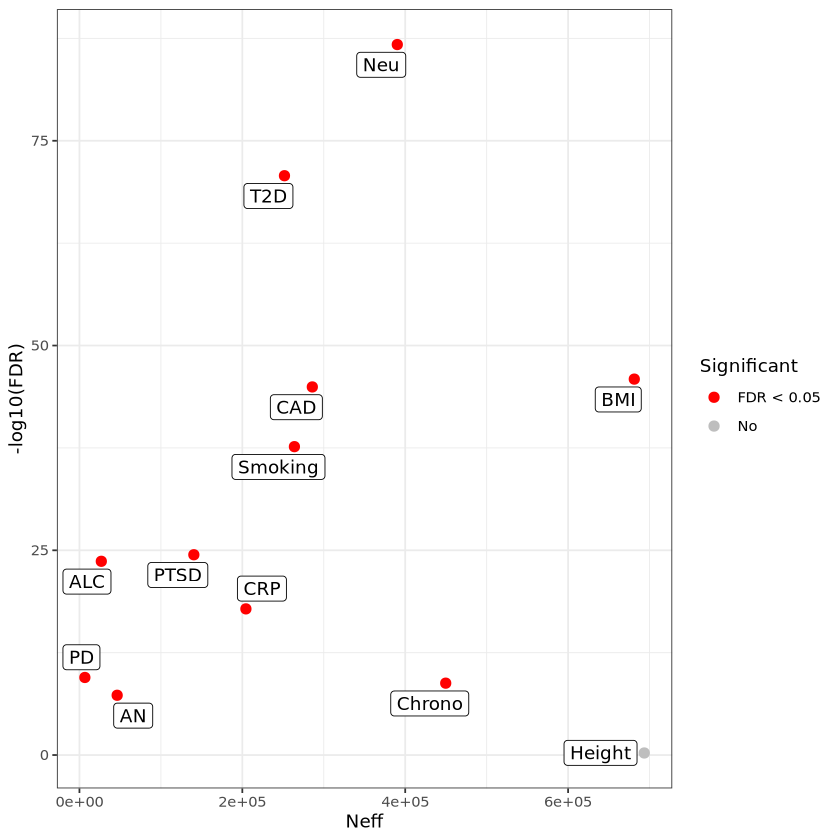

In [54]:
#create a dotplot with -log10(p) on the y axis and neff on the x axis

chisq_diff_plot <- ggplot(model_diff_neff_df, aes(x = Neff, y = -log10(FDR), label = Trait)) +
geom_point(aes(color = Significant), size = 2.5) +
scale_color_manual(values = c("red","grey")) +
theme_bw() +
geom_label_repel()

chisq_diff_plot

In [55]:
ggsave("../plots/jolien_paper/chisq_diff_bipolar.svg", chisq_diff_plot, width = 10, height = 10, create.dir = TRUE)

In [56]:
semPlotModel_GSEM <- function(gsem.object=cfa_bipolar){ 
        object <- gsem.object$results
        object$free=0
        numb=1:length(which(object$op!="~~"))
        object$free[which(object$op!="~~")]=numb
        varNames <- lavaanNames(object, type = "ov")
        factNames <- lavaanNames(object, type = "lv")
        factNames <- factNames[!factNames %in% varNames]
        n <- length(varNames)
        k <- length(factNames)
        if (is.null(object$label)) 
          object$label <- rep("", nrow(object))
        semModel <- new("semPlotModel")
        object$std <- object[,"STD_Genotype"]
        object$est <- object[,"Unstand_Est"]
        if (is.null(object$group)) 
          object$group <- ""
        semModel@Pars <- data.frame(label = object$label, lhs = ifelse(object$op == "~" | object$op == "~1", object$rhs, object$lhs), edge = "--", 
                                    rhs = ifelse(object$op == "~" | object$op == "~1", object$lhs, object$rhs), est = object$est, std = object$std, std = NA, group = object$group, 
                                    fixed = object$free==0, par = object$free, stringsAsFactors = FALSE)
        semModel@Pars$edge[object$op == "~~"] <- "<->"
        semModel@Pars$edge[object$op == "~*~"] <- "<->"
        semModel@Pars$edge[object$op == "~"] <- "~>"
        semModel@Pars$edge[object$op == "=~"] <- "->"
        semModel@Pars$edge[object$op == "~1"] <- "int"
        semModel@Pars$edge[grepl("\\|", object$op)] <- "|"
        semModel@Thresholds <- semModel@Pars[grepl("\\|", semModel@Pars$edge), 
                                             -(3:4)]
        semModel@Pars <- semModel@Pars[!object$op %in% c(":=", "<", 
                                                         ">", "==", "|", "<", ">"), ]
        semModel@Vars <- data.frame(name = c(varNames, factNames), 
                                    manifest = c(varNames, factNames) %in% varNames, exogenous = NA, 
                                    stringsAsFactors = FALSE)
        semModel@ObsCovs <- list()
        semModel@ImpCovs <- list()
        semModel@Computed <- FALSE
        semModel@Original <- list(object)
        return(semModel)
 }

In [57]:
library(lavaanPlot)
library(lavaan)
library(semPlot)

This is lavaan 0.6-20
lavaan is FREE software! Please report any bugs.



In [58]:
for (trait in other_names){
    #define the two sem objects
    current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[[trait]])
    current_fit_independent <- semPlotModel_GSEM(gsem.object = trait_independent.fit[[trait]])
    #extract the std estimate and the corresponding se to plot them both, for common and independent model
    se <- trait_common.fit[[trait]]$results$STD_Genotype_SE
    est <- trait_common.fit[[trait]]$results$STD_Genotype
    est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

    se_in <- trait_independent.fit[[trait]]$results$STD_Genotype_SE
    est_in <- trait_independent.fit[[trait]]$results$STD_Genotype
    est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")
    #save the common model as an svg object, remove the last label as overlapping and known as factor artificially set to variance of 1
    svg(paste0("/local1/home/pazweifel/plots/jolien_paper/",trait,"_common_model.svg"), width = 11, height = 12)
    semPaths(current_fit_common, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        esize = 2,
        edgeLabels = est.se[1:12])
    dev.off()
    #save the indpendent mode as an svg object
    svg(paste0("/local1/home/pazweifel/plots/jolien_paper/",trait,"_independent_model.svg"), width = 12, height = 11)
    semPaths(current_fit_independent, whatLabels = "std", layout = "circle2", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.45,
        edgeLabels = est.se_in)
    dev.off()
}

In [59]:
se <- base.fit$results$STD_Genotype_SE
est <- base.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

se_unstand <- base.fit$results$Unstand_SE
est_unstand <- base.fit$results$Unstand_Est
est.se_unstand <- paste0(round(as.numeric(est_unstand), 2),"\n (",round(as.numeric(se_unstand), 2),")")

se_in <- anchor.fit$results$STD_Genotype_SE
est_in <- anchor.fit$results$STD_Genotype
est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")

In [60]:
fit_sem_base <- semPlotModel_GSEM(base.fit)
fit_sem_anchor <- semPlotModel_GSEM(anchor.fit)

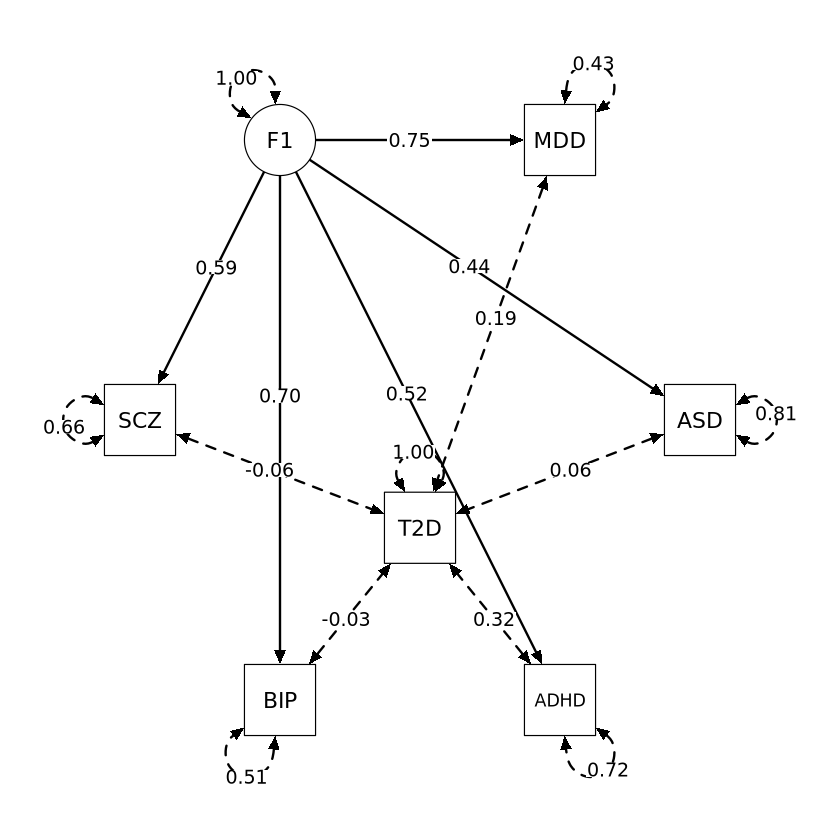

In [61]:
sem_neu_independent <- semPlotModel_GSEM(trait_independent.fit[["T2D"]])
#svg(paste0("/local1/home/pazweifel/plots/jolien_paper/","Neu","_independent_model.svg"), width = 12, height = 11)
semPaths(sem_neu_independent,  whatLabels = "std", layout = "circle2", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        edge.label.position = 0.45,
        esize = 2,
        edge.label.position = 0.5
        )
#dev.off()

agg_record_1566037414 
                    2

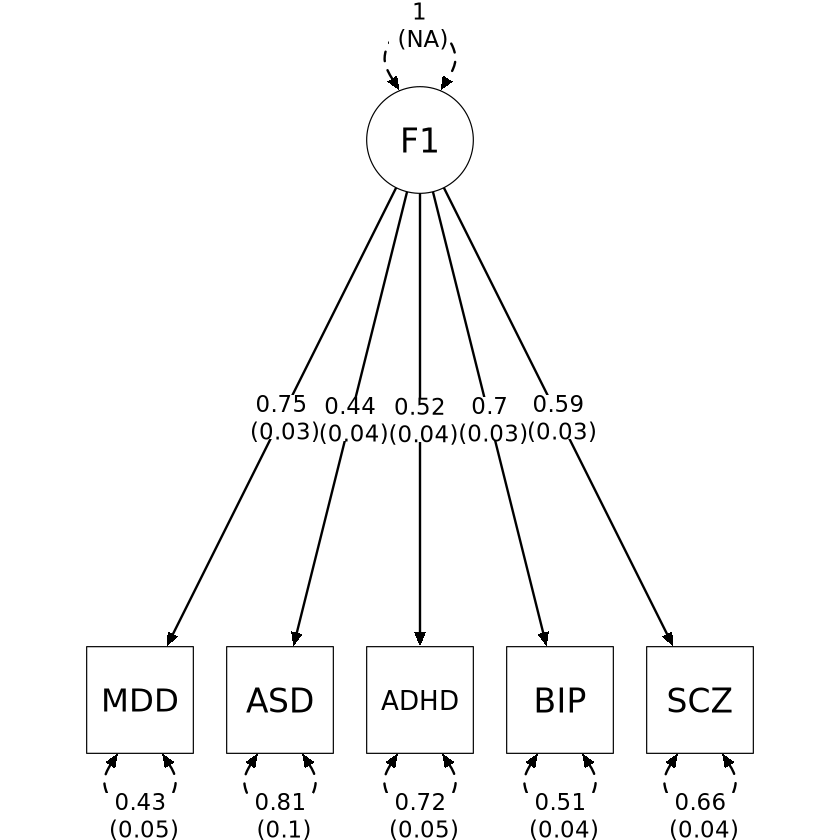

In [62]:
positions <- sapply(c(1:length(est.se)), function(index) {
    if (index%%2==0){
        0.7
    }else {
        0.3}
}
)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )

pdf("/local1/home/pazweifel/plots/jolien_paper/base_model_wse.pdf", width = 14, height = 14)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )
dev.off()

agg_record_1797989273 
                    2

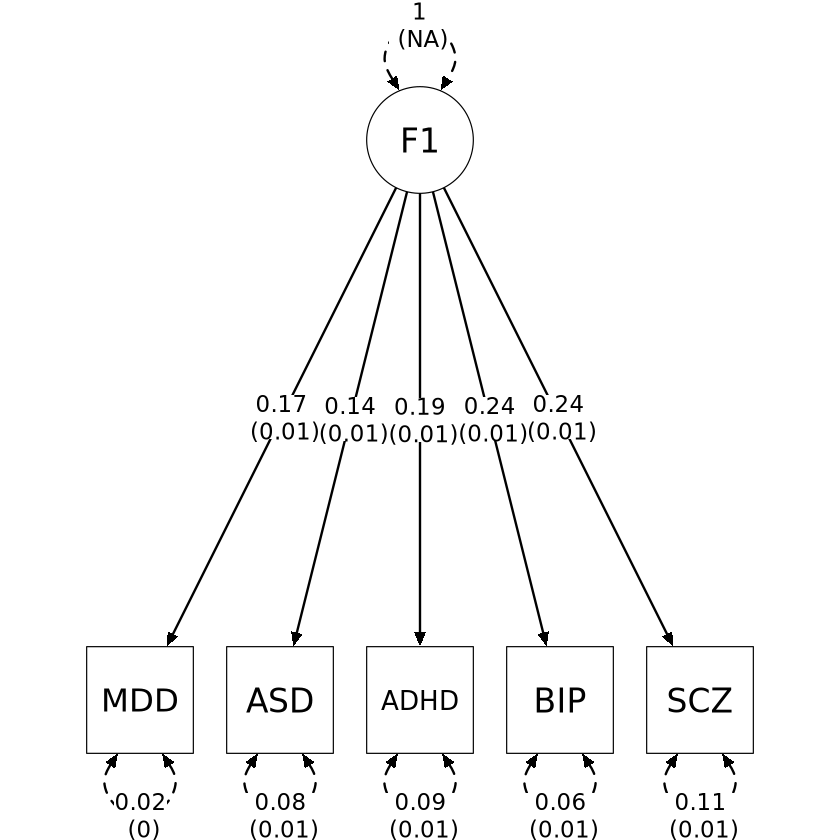

In [63]:
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_unstand,
        edge.label.position = 0.5
        )

pdf("/local1/home/pazweifel/plots/jolien_paper/base_model_wse_unstand.pdf", width = 14, height = 14)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_unstand,
        edge.label.position = 0.5
        )
dev.off()

In [64]:
base.fit$modelfit

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,346.9195,5,8.059206e-73,366.9195,0.8086939,0.1161236


In [65]:
anchor.fit$modelfit

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,346.9194,5,8.05992e-73,366.9194,0.808694,0.1161236


agg_record_1437630090 
                    2

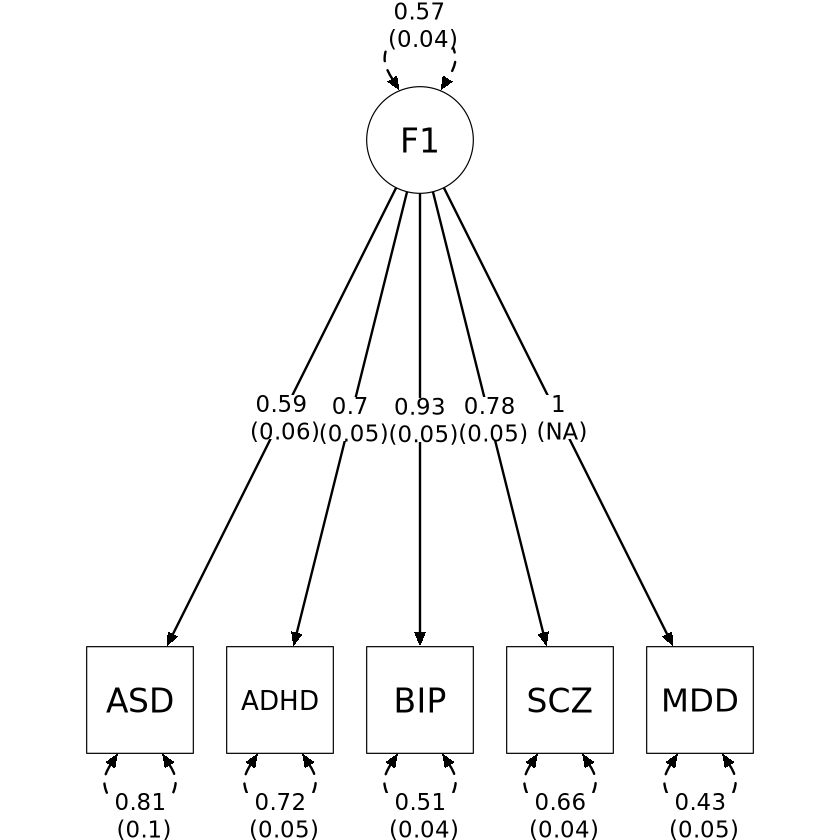

In [66]:
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_in)

svg("/local1/home/pazweifel/plots/jolien_paper/anchor_model_wse.svg", width = 10, height = 12)
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_in)
dev.off()

## GSEM Qtrait function to calculate 

In [67]:
trait.qtrait <- bind_rows(lapply(traits, function(trait) {
    QTrait(
    LDSCoutput = trait.covstructs[[trait]],
    indicators = mental_names,
    traits = trait)
    }),
    .id = "Trait")


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


corrplot 0.95 loaded




 ---------------------------- 

 Fitting common pathways model for external trait ALC 
 

 Fitting independent pathways model for external trait ALC 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait AN 
 

 Fitting independent pathways model for external trait AN 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait BMI 
 

 Fitting independent pathways model for external trait BMI 
 

 Fitting follow-up model for external trait BMI 
 

 Most egregious outlier: ADHD 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait CAD 
 

 Fitting independent pathways model for external trait CAD 
 

 Fitting follow-up model for external trait CAD 
 

 Most egregious outlier: ADHD 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 

In [68]:
trait.qtrait

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ALC,ALC,0.61916575,0.08268761,6.992505e-14,*,0.5858479,4,9.646233e-01,NS,0.16463261,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
AN,AN,0.34421099,0.03972553,4.525807e-18,*,54.7140723,4,3.729503e-11,*,0.05741093,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
BMI,BMI,0.09276086,0.01898930,1.034808e-06,*,186.0014525,4,3.832031e-39,*,0.14810104,⋯,6.782638e-02,NS,138.697711,3,7.215184e-30,*,0.08225136,No,No,ADHD
CAD,CAD,0.19208242,0.02209269,3.487018e-18,*,148.9376058,4,3.438565e-31,*,0.12880757,⋯,1.224025e-10,*,126.673419,3,2.817656e-27,*,0.09659964,No,No,ADHD
Chrono,Chrono,-0.07849411,0.02378841,9.679548e-04,*,52.9039905,4,8.925208e-11,*,0.06828902,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
CRP,CRP,0.10449121,0.02726885,1.271632e-04,*,251.2069852,4,3.577190e-53,*,0.11632447,⋯,1.514055e-02,*,217.476474,3,7.050394e-47,*,0.06781088,No,No,ADHD
Height,Height,-0.07080827,0.01607391,1.057015e-05,*,-3.7941860,4,1.000000e+00,NS,0.01871815,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
Neu,Neu,0.55080579,0.02797013,2.493299e-86,*,315.0623909,4,6.097977e-67,*,0.16152504,⋯,1.709708e-32,*,3.045614,3,3.846458e-01,NS,0.04511371,No,No,MDD
PD,PD,0.31633565,0.07926098,6.577744e-05,*,285.6320142,4,1.360202e-60,*,0.10649973,⋯,1.318222e-06,*,297.912341,3,2.815736e-64,*,0.05982439,No,No,BIP


In [69]:
help(QTrait)

QTrait {GenomicSEM},R Documentation
LDSCoutput,An object from the ldsc() function containing multivariate LDSC output.
indicators,A character vector specifying the names of indicator traits that define the latent factor. Must match trait names in LDSCoutput.
traits,A character vector of external traits for which QTrait statistics and genetic correlations will be estimated. Must match trait names in LDSCoutput.
mresid,A proportion (default = 0.25) of the RMS genetic correlation used to flag outlier indicator traits.
mresidthreshold,An absolute threshold (default = 0.10) for residual genetic correlation to define meaningful outliers.
lsrmr,Proportion (default = 0.25) used to define meaningful lSRMR based on the RMS genetic correlation.
lsrmrthreshold,Absolute threshold (default = 0.10) to define meaningful lSRMR.
save.plots,"Logical. If TRUE, saves scatterplots of trait–indicator associations against loadings. Default is TRUE."
stdout,"Logical. If TRUE, plots use standardized output (correlations vs. standardized loadings). If FALSE, uses covariances vs. unstandardized loadings. Default is TRUE."


## Visualization of Correlations for different models

In [70]:
cov2cor(trait_common.fit[["Neu"]]$resid_cov$'Model Implied Covariance Matrix')[1:5, 6]

ADHD       ASD       MDD       BIP       SCZ 
0.3140914 0.2241391 0.5851452 0.3091296 0.2672157

In [71]:
#first extract the model implied covariances from the common model fit and convert to correlations
target_common_rg <- bind_rows(
    lapply(trait_common.fit, function(fit) {
        cov2cor(V = fit$resid_cov$'Model Implied Covariance Matrix')[1:5, 6]
        }
    ),
    .id = "trait")
    

In [72]:
#add the common pathway label and make the df longer so that you have one correlation per line to plot afterwards
target_common_rg <- target_common_rg %>% mutate(Pathway = "Common") %>% pivot_longer(ADHD:SCZ, names_to = "Mental", values_to = "rg")

In [73]:
target_common_rg
trait_independent.fit[[1]]$results

trait,Pathway,Mental,rg
<chr>,<chr>,<chr>,<dbl>
ALC,Common,ADHD,0.34989556
ALC,Common,ASD,0.26411169
ALC,Common,MDD,0.49943433
ALC,Common,BIP,0.41413009
ALC,Common,SCZ,0.35055034
AN,Common,ADHD,0.17453121
AN,Common,ASD,0.14996113
AN,Common,MDD,0.26058197
AN,Common,BIP,0.24252983


,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
11,F1,=~,MDD,0.1685255661,0.0063889864760575,0.753616774,0.0285704455180743,0.753616771,2.482385e-153
9,F1,=~,ASD,0.1415289544,0.0137127538448607,0.441522459,0.0427792034561069,0.441522617,5.664650e-25
8,F1,=~,ADHD,0.1880907139,0.0125784681970348,0.524560202,0.0350797102113635,0.524560503,1.480230e-50
10,F1,=~,BIP,0.2388958698,0.00992279798977375,0.701188317,0.0291245723315575,0.701187903,4.519672e-128
12,F1,=~,SCZ,0.2423182596,0.0121650051172027,0.585200426,0.0293785897643834,0.585200338,2.768913e-88
14,MDD,~~,ALC,0.0436030971,0.00438291101222133,0.566366298,0.0569301873608124,0.861638175,2.561849e-23
4,ASD,~~,ALC,0.0002652566,0.00972184199757598,0.002404754,0.0880950114098724,0.002680141,9.782327e-01
2,ADHD,~~,ALC,0.0632667756,0.00845135416550398,0.512506257,0.0684619647595975,0.601977013,7.100834e-14
6,BIP,~~,ALC,0.0360532178,0.0072293429241005,0.307371659,0.0616337966985665,0.431110679,6.130280e-07


In [74]:
#now extract correlation of external phenotype with common factor form results table (F1~~E)
target_common_factor_rg <- bind_rows(
    lapply(trait_common.fit, function(fit){
        fit$results %>%
        filter(
            lhs == "F1",
            rhs != "F1",
            !rhs %in% mental_names
            ) %>%
        transmute(Mental = "F1", rg = STD_Genotype, se = as.numeric(STD_Genotype_SE)
                  )
        }
    ),
    .id = "trait"
    ) %>%
    mutate(Pathway = "Common")

In [75]:
#now the same for the independent model, extract from model-implied covariance matrix
target_independent_rg <- bind_rows(
    lapply(
        trait_independent.fit, function(fit){
            cov2cor(fit$resid_cov$'Model Implied Covariance Matrix')[1:5, 6]
            }),
    .id = "trait"
    ) %>% mutate(Pathway = "Independent") %>% pivot_longer(ADHD:SCZ, names_to = "Mental", values_to = "rg")

In [76]:
#for the independent model extract the correlation between factor and external trait form results
target_independent_rg_se <- bind_rows(
    lapply(trait_independent.fit, function(fit){
        fit$results %>% filter(
            lhs %in% mental_names,
            lhs != rhs
            ) %>% transmute(
            Mental = lhs, rg = STD_Genotype, se = as.numeric(STD_Genotype_SE))
        }),
        .id = "trait"
    ) %>% mutate(
    Pathway = "Independent")
        

In [77]:

target_sample_sizes <-
  bind_rows(
    lapply(trait.covstructs, function(covs) {
      # get sample sizes
      N <- covs$N
      # create a matrix the same size as the cov matrix
      Nmat <- covs$S
      # fill in lower triangle
      Nmat[TRUE] <- NA
      Nmat[lower.tri(Nmat, diag = TRUE)] <- N
      # extract sample size and names from matrix
      Ns <- Nmat[6, 1:5]
      N_names <- dimnames(Nmat)[[2]][1:5]
      # add total N for factor
      N_total <- sum(Ns)
      tibble(N = c(Ns, N_total), Mental = c(N_names, "F1"))
    }),
    .id = "trait"
  )

In [78]:
target_rg <- bind_rows(
    target_common_rg, 
    target_common_factor_rg, 
    target_independent_rg_se) %>% left_join(
    target_sample_sizes,
    by = c("trait", "Mental")) %>% left_join(
    model_diff_neff_df, by = c("trait" = "Trait"))

In [79]:
correlations_table <- target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)) %>% select(-c(Nca, Nco, Neff, Significant))


In [80]:
correlation_plot <- ggplot(
  target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = Mental, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait)) +
  scale_x_discrete("Mental phenotype", limits = c("F1", rev(mental_names))) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal() +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1))

Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale r

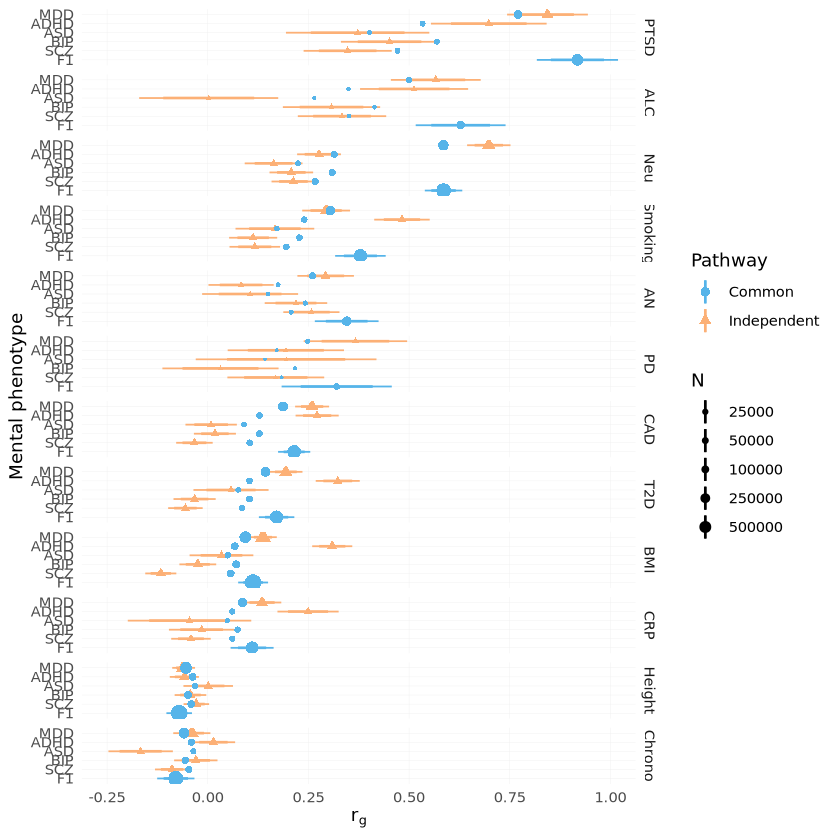

In [81]:
correlation_plot

In [82]:
ggsave("/local1/home/pazweifel/plots/jolien_paper/Correlation_comparison.svg", plot = correlation_plot, width = 10, height = 25, device = "svg") 

Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale r

In [83]:
target_rg |>
    pivot_wider(names_from = c("Pathway"), values_from = c("rg", "se")) |>
    mutate(rgD = rg_Independent - rg_Common) |>
    select(-se_Common) |>
    arrange(desc(abs(rgD))) |>
    filter(abs(rgD) > se_Independent) |> select(-c(Nca, Nco, Neff, Significant))


trait,Mental,N,q_chisq,q_df,q_p,FDR,rg_Common,rg_Independent,se_Independent,rgD
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ALC,ASD,33284.09,118.19954,4,1.294698e-24,2.219482e-24,0.26411169,0.002404754,0.08809501,-0.26170694
Smoking,ADHD,182410.91,184.21728,4,9.262254e-39,2.222941e-38,0.23952235,0.482361816,0.03515353,0.24283947
BMI,ADHD,295901.41,223.59586,4,3.155569e-47,1.262228e-46,0.06710756,0.309192060,0.02541057,0.24208450
T2D,ADHD,178945.14,339.60796,4,3.073027e-72,1.843816e-71,0.10364754,0.322880581,0.02789465,0.21923304
CRP,ADHD,161265.62,90.65832,4,9.542223e-19,1.431333e-18,0.06060165,0.249129719,0.03877795,0.18852807
PD,BIP,30768.93,50.72914,4,2.542894e-10,3.390526e-10,0.21730920,0.031684374,0.07360459,-0.18562483
BMI,SCZ,294419.07,223.59586,4,3.155569e-47,1.262228e-46,0.05701917,-0.116570146,0.01968809,-0.17358932
PTSD,ADHD,133517.67,122.26267,4,1.755127e-25,3.510255e-25,0.53355731,0.698009276,0.07328433,0.16445197
ALC,ADHD,56100.11,118.19954,4,1.294698e-24,2.219482e-24,0.34989556,0.512506257,0.06846196,0.16261069


## Follow-up models: Removing external ~ internal trait regressions one by one to compare model fit

In [84]:
rg_ordered_grouped_df <- target_rg %>% filter(Pathway == "Independent") %>% group_by(trait) %>% arrange(-rg, .by_group = TRUE) %>% subset(select = c(trait, Mental, rg))

In [85]:
rg_ordered_grouped_df

trait,Mental,rg
<chr>,<chr>,<dbl>
ALC,MDD,0.566366298
ALC,ADHD,0.512506257
ALC,SCZ,0.333477966
ALC,BIP,0.307371659
ALC,ASD,0.002404754
AN,MDD,0.292863913
AN,SCZ,0.257415760
AN,BIP,0.219117767
AN,ASD,0.105257265


In [86]:
vec <- filter(rg_ordered_grouped_df, trait == "ADHD") %>% .$BD %>% .[1:(4-1)]
vec[5]

Warning message:
“Unknown or uninitialised column: `BD`.”


NULL

In [87]:
dynamic_model_1 <- "F1=~NA*Clinical+Community+BDI+BDII
{external_trait}~~{trait1}
{external_trait}~~{trait2}
{external_trait}~~{trait3}
"

dynamic_model_2 <- "F1~~1*F1
Clinical~~a*Clinical
a>0.0001
"

paste0(dynamic_model_1,dynamic_model_2)
dynamic_model_1
substr(dynamic_model_1, 1, nchar(dynamic_model_1))

[1] "F1=~NA*Clinical+Community+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\nF1~~1*F1\nClinical~~a*Clinical\na>0.0001\n"

[1] "F1=~NA*Clinical+Community+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\n"

[1] "F1=~NA*Clinical+Community+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\n"

In [88]:
sub <- nchar("{external_trait}~~{traitx}\n")
a <- substr(dynamic_model_1, 1, nchar(dynamic_model_1) - 2 * sub)

paste0(a,dynamic_model_2)
#trait 1 the one with the highest loading 

[1] "F1=~NA*Clinical+Community+BDI+BDII\n{external_trait}~~{trait1}\nF1~~1*F1\nClinical~~a*Clinical\na>0.0001\n"

In [89]:
#lsit where i want to store the different follow up models with stepwise retracted traits
fitlist <- list(follow_up_1 = 0, follow_up_2 = 0, follow_up_3 = 0)

In [90]:
#list where i want to store the different follow up models with stepwise retracted traits
fitlist <- list(follow_up_1 = 0, follow_up_2 = 0, follow_up_3 = 0)

dynamic_model_1 <- "F1=~NA*Clinical+Community+BDI+BDII
F1~~1*F1
{trait1}~~{external_trait}
{trait2}~~{external_trait}
{trait3}~~{external_trait}
"

dynamic_model_2 <- "F1~b*{external_trait}
Clinical~~a*Clinical
a>0.0001
"

sub <- nchar("{external_trait}~~{traitx}\n")


for (index in 1:3){
    temp.fit <- lapply(traits, function(external_trait){
        #extract the internal traits ordered by rg; depending on index remove the one with the lowest correlation and store them in a vector
        trait_vector <- filter(rg_ordered_grouped_df, trait == external_trait) %>% .$BD %>% .[1:(4-index)]
        #assign values form vector to trait variables which match the placeholders in the dynamic model, if out of range jsut gets NA so no problem
        trait1 <- trait_vector[1]
        trait2 <- trait_vector[2]
        trait3 <- trait_vector[3]
        #adjust the model
        temp_model <- substr(dynamic_model_1, 1, nchar(dynamic_model_1) - (index -1) * sub)
        print(temp_model)
        #paste the traits into the model structure
        temp_model <- str_glue(temp_model)
        temp_model_2 <- str_glue(dynamic_model_2)
        print(temp_model)
        temp_model <- paste(temp_model, temp_model_2, sep = "\n")
        print(temp_model)
        usermodel(
                trait.covstructs[[external_trait]],
                estimation = "DWLS",
                model = temp_model,
                imp_cov = TRUE
                )
            }
        )
    fitlist[[index]] <- temp.fit
}


Warning message:
“Unknown or uninitialised column: `BD`.”


[1] "F1=~NA*Clinical+Community+BDI+BDII\nF1~~1*F1\n{trait1}~~{external_trait}\n{trait2}~~{external_trait}\n{trait3}~~{external_trait}\n"
[1] "\nF1~b*ALC\nClinical~~a*Clinical\na>0.0001"


ERROR: Error in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", : None of the trait names in the LDSC output match names in the model


In [ ]:
fitlist$follow_up_3[["ADHD"]]

In [ ]:
for (i in fitlist){
    tempsem <- semPlotModel_GSEM(i[["Neu"]])
      semPaths(tempsem, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.7)
    print(i[["Neu"]]$modelfit$chisq)
    }
print(trait_common.fit[["Neu"]]$modelfit$chisq)    
print(trait_independent.fit[["Neu"]]$modelfit$chisq)  